# 선문대학교 컴퓨터공학부
# 2022243101 최완우

## 선형회귀 실습
### 캘리포니아의 집 가격을 비교하여 예측하는 학습

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. 데이터 불러오기
housing = fetch_california_housing()
print(housing.DESCR)

X = pd.DataFrame(housing.data, columns=housing.feature_names)

y = pd.Series(housing.target, name="MedHouseValue")


.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [55]:
# X와 y를 합친 data 생성
data = pd.concat([X, y], axis = 1)
# 인덱스 개수 확인
data

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [56]:
# 상위 5줄 출력
data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [57]:
# 컬럼 정보 출력
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MedInc         20640 non-null  float64
 1   HouseAge       20640 non-null  float64
 2   AveRooms       20640 non-null  float64
 3   AveBedrms      20640 non-null  float64
 4   Population     20640 non-null  float64
 5   AveOccup       20640 non-null  float64
 6   Latitude       20640 non-null  float64
 7   Longitude      20640 non-null  float64
 8   MedHouseValue  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [58]:
# 통계 정보 출력
data.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [59]:
# 소수점 2째자리까지만 표시해 통계 정보 출력
round(data.describe(), 2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


In [60]:
# 데이터셋 분할(테스트 30% / 학습 70%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 100)

In [61]:
model = LinearRegression()
model.fit(X_train, y_train)
pred = model.predict(X_test)        # X_test : 예측 대상

In [62]:
# 테이블로 평가하기
comparison = pd.DataFrame({'actual' : y_test, 'pred' : pred})
comparison

,actual,pred
8151,2.453,2.086920
53,1.042,1.588411
3039,1.462,2.092174
9484,1.542,1.591352
9307,3.242,2.049706
...,...,...
11584,2.376,2.901033
2767,0.543,0.888247
9481,0.840,1.408364
2258,0.656,1.494365


<Axes: xlabel='actual', ylabel='pred'>

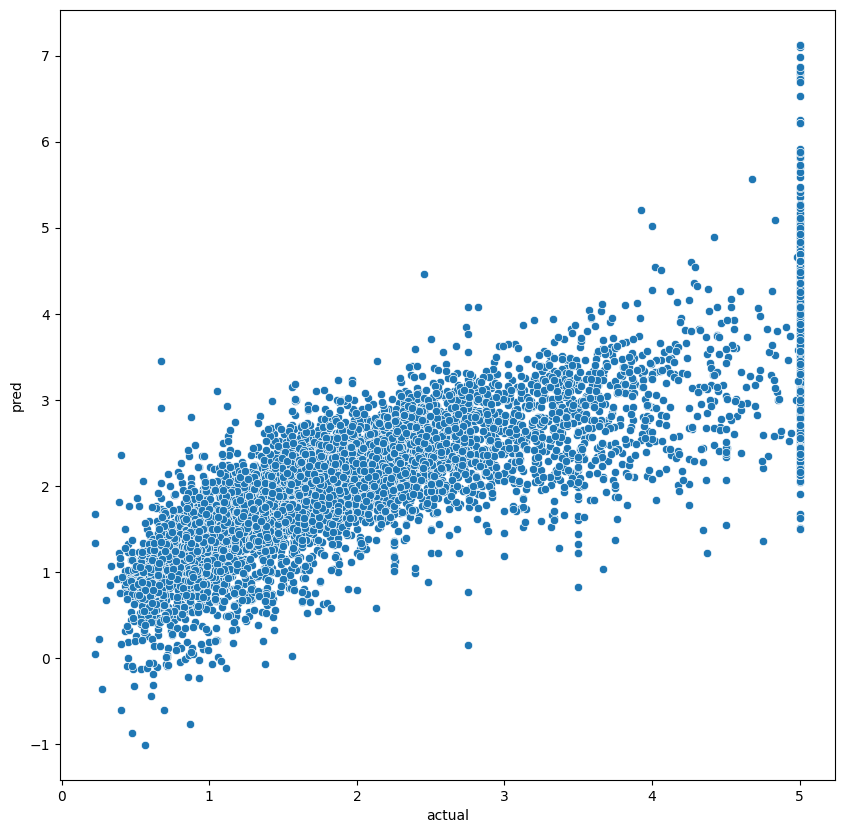

In [63]:
# 그래프로 평가하기
plt.figure(figsize=(10, 10))
sns.scatterplot(x = 'actual', y = 'pred', data = comparison)

<Axes: >

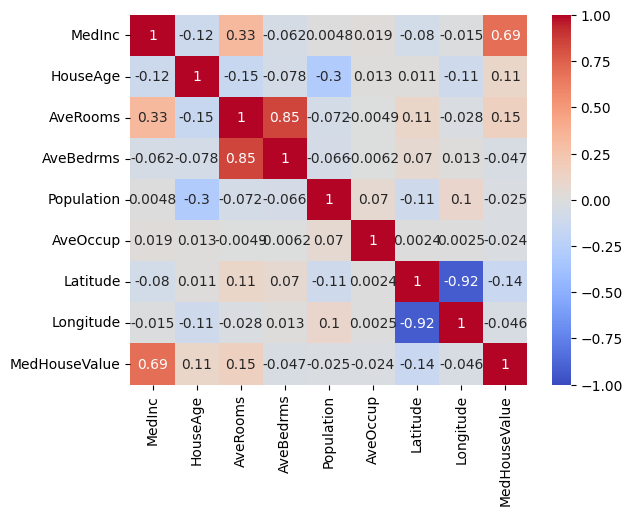

In [64]:
# 히트맵으로 평가하기
sns.heatmap(data.corr(), cmap = 'coolwarm', vmin = -1, vmax = 1, annot = True)

In [65]:
# 통계적 평가지표
mse = mean_squared_error(y_test, pred)
rmse = mse ** 0.5
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)     

print(f"mse : {mse}")
print(f"rmse : {rmse}")
print(f"mae : {mae}")
print(f"r2 = {r2}")

mse : 0.5004697085848051
rmse : 0.7074388373455369
mae : 0.5258541695643579
r2 = 0.6221318111480791


In [66]:
# 기울기 알아보기
print(f"기울기 : {model.coef_} \n\n {pd.Series(model.coef_, index = X.columns)}")

기울기 : [ 4.29542639e-01  9.57389628e-03 -1.00249455e-01  6.06712768e-01
 -4.09124666e-06 -3.91058923e-03 -4.22903357e-01 -4.36869378e-01] 

 MedInc        0.429543
HouseAge      0.009574
AveRooms     -0.100249
AveBedrms     0.606713
Population   -0.000004
AveOccup     -0.003911
Latitude     -0.422903
Longitude    -0.436869
dtype: float64


In [67]:
# y 절편 알아보기
print(f"y 절편 : {model.intercept_}")

y 절편 : -37.13412182840413
